<font size=10>Spark Tutorial</font>

# Introduction
In this laboratory, we will cover the basic element of programming using a map-reduce methodology. For that purpose, we will be using Apache Spark as a reference, but bear in mind that similar frameworks exists and principles can be extrapolated.

## Some concepts and facts

- Spark is a distributed computing platform that operates on a cluster. Like MPI, we expect that nodes does NOT share a memory space but they are connected in high-speed dedicated network. Distributed filesystems that work over the network are extremely useful.

- It is considered the next generation of previous map-reduce standard Apache Hadoop. Main difference is thought to be the use of the memory instead of disk for intermediate operations, but there are many more improvements.

- It is built on Java. Despite this, it can be programmed using Java, Scala, Python or R. The complete API can only be found in JVM-based languages but the most frequent one is PySpark, since people is reluctant to use JVM-based languages in data science. Indeed, since Hadoop was only available for Java, it is likely that some Java codes of Spark are adaptations of previous Hadoop codes.

- Resilient Distributed Dataset (RDD): the basic unit that is processed in Spark. Equivalent to a numpy array but distributed.

- RDD API usually exposes the low-level operations of Apache Spark, useful for preprocessing data but useless for data analytics

- For data analysis, Dataframe and Spark SQL is used. It relies on a pandas-alike API that even accepts SQL code (which may sound crazy and useless for developers, but many *old* data scientists and statisticians are really proficient in SQL but not in Python).

## How to install Spark

Colab already has Apache Spark and the Apache Spark client for Python (pyspark) installed.



In [129]:
#spark_version = "3.5.8"
#hadoop_version = "3"

#!apt-get update
#!apt-get install openjdk-8-jdk-headless -qq # Install JVM v8
#!wget -O spark-{spark_version}-bin-hadoop{hadoop_version}.tgz -q https://downloads.apache.org/spark/spark-{spark_version}/spark-{spark_version}-bin-hadoop{hadoop_version}.tgz # Download latest release. Update if necessary
#!tar xf spark-{spark_version}-bin-hadoop{hadoop_version}.tgz # Unzip
#import os
#os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
#os.environ["SPARK_HOME"] = f"/content/spark-{spark_version}-bin-hadoop{hadoop_version}"

In [130]:
#%pip install pyspark>=4.0.0

## How to initialize Spark

In [131]:
import os
os.environ['SPARK_HOME'] = '/opt/homebrew/Cellar/apache-spark/4.1.1/libexec'
os.environ['JAVA_HOME'] = '/Library/Java/JavaVirtualMachines/temurin-21.jdk/Contents/Home'

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("PruebaEntornoMac").getOrCreate()
sc = spark.sparkContext

# First Part: RDDs

## Basic operations

### Parallelize & collect

It creates a RDD out of a list or array. Second argument indicates the number of pieces of the RDD

In [132]:
array = sc.parallelize([1,2,3,4,5,6,7,8,9,10], 2)
array

ParallelCollectionRDD[463] at readRDDFromFile at PythonRDD.scala:299

In [133]:
import numpy as np
randomSamples = sc.parallelize(np.random.randn(100))
randomSamples

ParallelCollectionRDD[464] at readRDDFromFile at PythonRDD.scala:299

Cool, RDDs can not be printed...

Of course, RDDs can not be printed unless they are reduced

In [134]:
print(array.collect())
print(randomSamples.collect())

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0.6824494942109096, 0.06084135809908856, -0.9797651387383601, 2.1488500403535546, 1.0296318713227006, 0.08031697995248335, 0.1626621572682951, 1.0771343763786665, -0.08882902381488261, -1.9822532959586472, 0.02608320462246117, -0.05427898302213498, 0.11180703578903509, -0.8106663068003315, 0.939508315935009, -0.06394392717442002, 0.5396166490531482, -1.7785926290599772, 0.4302687443851244, -0.5706796997386127, -0.8056240429063225, -0.748595231490692, 0.7960937186613808, -0.16218703071384652, 0.9713067711202069, 3.3784412213304376, -1.0808219671308679, -0.7644309665336222, 1.46078629464272, 0.3030849027308883, -0.13078511739397813, 0.44352599219103633, -0.10813598333087333, -1.4291161255064342, 0.40079520768583193, 1.2064114624353164, 0.2960080410133416, 1.3909104393933291, 0.8287249066347298, -1.2018961504807815, -0.6611417784847519, -0.2879387028459775, 0.41320971001024986, -0.2202214247293351, 0.2236477612151723, 0.3347409200590609, 0.2694379553692427

Spark uses lazy operations for everything, this means that nothing is evaluated until an action, a reduce operation normally, is performed. The basic reduce operation is collect, which returns the whole RDD (i.e. no reduction is performed).

### Other ways of loading data

In [135]:
import requests

request = requests.get("https://gist.githubusercontent.com/jsdario/6d6c69398cb0c73111e49f1218960f79/raw/8d4fc4548d437e2a7203a5aeeace5477f598827d/el_quijote.txt")
with open("elquijote.txt", "wb") as f:
  f.write(request.content)

In [136]:
quijote = sc.textFile("elquijote.txt")
quijote.take(10)

['DON QUIJOTE DE LA MANCHA',
 'Miguel de Cervantes Saavedra',
 '',
 'PRIMERA PARTE',
 'CAPÍTULO 1: Que trata de la condición y ejercicio del famoso hidalgo D. Quijote de la Mancha',
 'En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua, rocín flaco y galgo corredor. Una olla de algo más vaca que carnero, salpicón las más noches, duelos y quebrantos los sábados, lentejas los viernes, algún palomino de añadidura los domingos, consumían las tres partes de su hacienda. El resto della concluían sayo de velarte, calzas de velludo para las fiestas con sus pantuflos de lo mismo, los días de entre semana se honraba con su vellori de lo más fino. Tenía en su casa una ama que pasaba de los cuarenta, y una sobrina que no llegaba a los veinte, y un mozo de campo y plaza, que así ensillaba el rocín como tomaba la podadera. Frisaba la edad de nuestro hidalgo con los cincuenta años, era de 

Here, you can see both a method to load a text file line per line and a another reduction operation.

In [137]:
quijote.take?

Signature: quijote.take(num: int) -> List[~T]
Docstring:
Take the first num elements of the RDD.

It works by first scanning one partition, and use the results from
that partition to estimate the number of additional partitions needed
to satisfy the limit.

Translated from the Scala implementation in RDD#take().

.. versionadded:: 0.7.0

Parameters
----------
num : int
    first number of elements

Returns
-------
list
    the first `num` elements

See Also
--------
:meth:`RDD.first`
:meth:`pyspark.sql.DataFrame.take`

Notes
-----
This method should only be used if the resulting array is expected
to be small, as all the data is loaded into the driver's memory.

Examples
--------
>>> sc.parallelize([2, 3, 4, 5, 6]).cache().take(2)
[2, 3]
>>> sc.parallelize([2, 3, 4, 5, 6]).take(10)
[2, 3, 4, 5, 6]
>>> sc.parallelize(range(100), 100).filter(lambda x: x > 90).take(3)
[91, 92, 93]
File:      ~/anaconda3/lib/python3.11/site-packages/pyspark/core/rdd.py
Type:      method

### Transformations

Let's review all the transformation that can be performed to data.

In [138]:
charsPerLine = quijote.map(lambda s: len(s))
allWords = quijote.flatMap(lambda s: s.split())
allWordsNoArticles = allWords.filter(lambda a: a.lower() not in ["el", "la"])
allWordsUnique = allWords.map(lambda s: s.lower()).distinct()
sampleWords = allWords.sample(withReplacement=True, fraction=0.2, seed=666)
weirdSampling = sampleWords.union(allWordsNoArticles.sample(False, fraction=0.3))

In [139]:
allWordsUnique.take(10)

['don',
 'quijote',
 'la',
 'miguel',
 'cervantes',
 '1:',
 'condición',
 'ejercicio',
 'famoso',
 'hidalgo']

--------


<font size=10 color=red>Assignment question</font>

Explain the use and purpose of each operation above.

Comment also on the size of the resulting RDD in terms of the size of the original RDD, e.g. if original RDD is of size $N$, then rdd.filter() is of size $K\leq N$

--------
Answer:
- map
- flatMap
- filter
- distinct
- sample
- union

----

 ### Actions



In [140]:
numLines = quijote.count()
numChars = charsPerLine.reduce(lambda a,b: a+b) # also charsPerLine.sum()
sortedWordsByLength = allWordsNoArticles.takeOrdered(10, key=lambda x: -len(x))
numLines, numChars, sortedWordsByLength

(2186,
 1036211,
 ['procuremos.Levántate,',
  'extraordinariamente,',
  'estrechísimamente,',
  'convirtiéndoseles',
  'entretenimientos,',
  'inadvertidamente.',
  'cortesísimamente',
  'Agredeciéronselo',
  'Pintiquiniestra,',
  'entretenimiento,'])

--------


<font size=10 color=red>Assignment question</font>

Explain the use and purpose of each action above.

Implement the count operation using reduce as the unique option. You can use transformations. Is it possible to achieve a solution without any transformation? Does it make sense?

--------
Answer:


----

## Key-Value RDDs

In [141]:
import re
allWords = allWords.flatMap(lambda w: re.sub(""";|:|\.|,|-|–|"|'|\s"""," ", w.lower()).split(" ")).filter(lambda a: len(a)>0)
allWords2 = sc.parallelize(requests.get("https://gist.githubusercontent.com/jsdario/9d871ed773c81bf217f57d1db2d2503f/raw/585de69b0631c805dabc6280506717943b82ba4a/el_quijote_ii.txt").iter_lines())
allWords2 = allWords2.flatMap(lambda w: re.sub(""";|:|\.|,|-|–|"|'|\s"""," ", w.decode("utf8").lower()).split(" ")).filter(lambda a: len(a)>0)

In [142]:
allWords.take(10), allWords2.take(10)

(['don',
  'quijote',
  'de',
  'la',
  'mancha',
  'miguel',
  'de',
  'cervantes',
  'saavedra',
  'primera'],
 ['don',
  'quijote',
  'de',
  'la',
  'mancha',
  'miguel',
  'de',
  'cervantes',
  'saavedra',
  'segunda'])

Next, we move to more interesting operations that involve key-value RDDs. Key-value RDDs are a special kind of RDDs where each is element is a tuple (K,V) where K is the key and V the value.

In [143]:
words = allWords.map(lambda e: (e,1))
words2 = allWords2.map(lambda e: (e,1))

words.take(10)

[('don', 1),
 ('quijote', 1),
 ('de', 1),
 ('la', 1),
 ('mancha', 1),
 ('miguel', 1),
 ('de', 1),
 ('cervantes', 1),
 ('saavedra', 1),
 ('primera', 1)]

### How to manipulate K-V RDDs

In [144]:
frequencies = words.reduceByKey(lambda a,b: a+b)
frequencies2 = words2.reduceByKey(lambda a,b: a+b)
frequencies.takeOrdered(10, key=lambda a: -a[1])

[('que', 10705),
 ('de', 9033),
 ('y', 8668),
 ('la', 5015),
 ('a', 4815),
 ('en', 4046),
 ('el', 3857),
 ('no', 3083),
 ('se', 2382),
 ('los', 2148)]

In [145]:
res = words.groupByKey().takeOrdered(10, key=lambda a: -len(a))
res # To see the content, res[i][1].data

[('don', <pyspark.resultiterable.ResultIterable at 0x30cc46990>),
 ('quijote', <pyspark.resultiterable.ResultIterable at 0x16be0ac10>),
 ('la', <pyspark.resultiterable.ResultIterable at 0x30ce86f90>),
 ('miguel', <pyspark.resultiterable.ResultIterable at 0x16bdc8090>),
 ('cervantes', <pyspark.resultiterable.ResultIterable at 0x30c941590>),
 ('condición', <pyspark.resultiterable.ResultIterable at 0x16b549a10>),
 ('ejercicio', <pyspark.resultiterable.ResultIterable at 0x16b534f90>),
 ('famoso', <pyspark.resultiterable.ResultIterable at 0x16b534390>),
 ('hidalgo', <pyspark.resultiterable.ResultIterable at 0x16ad64910>),
 ('d', <pyspark.resultiterable.ResultIterable at 0x16ad64610>)]

In [146]:
joinFreq = frequencies.join(frequencies2)
joinFreq.take(10)

[('una', (601, 764)),
 ('olla', (3, 5)),
 ('calzas', (3, 5)),
 ('mismo', (120, 106)),
 ('casa', (144, 186)),
 ('complexión', (1, 3)),
 ('rostro', (69, 89)),
 ('caso', (70, 59)),
 ('pero', (435, 599)),
 ('libros', (106, 30))]

In [147]:
joinFreq.map(lambda e: (e[0], (e[1][0] - e[1][1])/(e[1][0] + e[1][1]))).takeOrdered(10, lambda v: -v[1]), joinFreq.map(lambda e: (e[0], (e[1][0] - e[1][1])/(e[1][0] + e[1][1]))).takeOrdered(10, lambda v: +v[1])

([('bacía', 0.9393939393939394),
  ('venia', 0.9230769230769231),
  ('hermandad', 0.9),
  ('andrés', 0.8823529411764706),
  ('micomicona', 0.8823529411764706),
  ('peña', 0.8823529411764706),
  ('barca', 0.875),
  ('yerme', 0.875),
  ('novela', 0.875),
  ('acertó', 0.8666666666666667)],
 [('teresa', -0.9767441860465116),
  ('roque', -0.96),
  ('refranes', -0.9375),
  ('condesa', -0.9333333333333333),
  ('leones', -0.9333333333333333),
  ('lacayo', -0.9166666666666666),
  ('gobernadores', -0.9166666666666666),
  ('visorrey', -0.9130434782608695),
  ('antonio', -0.9076923076923077),
  ('zaragoza', -0.9047619047619048)])

--------


<font size=10 color=red>Assignment question</font>

Explain the use and purpose of each action above.

Implement the frequency with groupByKey and transformations.

Which of the two following cells is more efficient?

--------
Answer:


------

In [148]:
joinFreq.map(lambda e: (e[0], (e[1][0] - e[1][1])/(e[1][0] + e[1][1]))).takeOrdered(10, lambda v: -v[1]), joinFreq.map(lambda e: (e[0], (e[1][0] - e[1][1])/(e[1][0] + e[1][1]))).takeOrdered(10, lambda v: +v[1])

([('bacía', 0.9393939393939394),
  ('venia', 0.9230769230769231),
  ('hermandad', 0.9),
  ('andrés', 0.8823529411764706),
  ('micomicona', 0.8823529411764706),
  ('peña', 0.8823529411764706),
  ('barca', 0.875),
  ('yerme', 0.875),
  ('novela', 0.875),
  ('acertó', 0.8666666666666667)],
 [('teresa', -0.9767441860465116),
  ('roque', -0.96),
  ('refranes', -0.9375),
  ('condesa', -0.9333333333333333),
  ('leones', -0.9333333333333333),
  ('lacayo', -0.9166666666666666),
  ('gobernadores', -0.9166666666666666),
  ('visorrey', -0.9130434782608695),
  ('antonio', -0.9076923076923077),
  ('zaragoza', -0.9047619047619048)])

In [149]:
result = joinFreq.map(lambda e: (e[0], (e[1][0] - e[1][1])/(e[1][0] + e[1][1])))
result.takeOrdered(10, lambda v: -v[1]), result.takeOrdered(10, lambda v: +v[1])

([('bacía', 0.9393939393939394),
  ('venia', 0.9230769230769231),
  ('hermandad', 0.9),
  ('andrés', 0.8823529411764706),
  ('micomicona', 0.8823529411764706),
  ('peña', 0.8823529411764706),
  ('barca', 0.875),
  ('yerme', 0.875),
  ('novela', 0.875),
  ('acertó', 0.8666666666666667)],
 [('teresa', -0.9767441860465116),
  ('roque', -0.96),
  ('refranes', -0.9375),
  ('condesa', -0.9333333333333333),
  ('leones', -0.9333333333333333),
  ('lacayo', -0.9166666666666666),
  ('gobernadores', -0.9166666666666666),
  ('visorrey', -0.9130434782608695),
  ('antonio', -0.9076923076923077),
  ('zaragoza', -0.9047619047619048)])

## Optimizations and final notes

### Optimizing the data movement around the cluster

One of the main issues could be that if data after an operation is not balanced, we may not be using the cluster properly. For that purpose, we have two operations


In [150]:
result.coalesce(numPartitions=2) # Avoids the data movement, so it tries to balance inside each machine
result.repartition(numPartitions=2) # We don't care about data movement, this balance the whole thing to ensure all machines are used

MapPartitionsRDD[517] at coalesce at NativeMethodAccessorImpl.java:0

### Persistance for intermediate operations
In contrast to Hadoop, intermediate RDDs are not preserved, each time we use an action/reduction, the whole data pipeline is executed from the datasources. To avoid this:


In [151]:
result.take(10)
allWords.cache() # allWords RDD must  stay in memory after computation, we made a checkpoint (well, it's a best effort, so must might be too strong)
result.take(10)

[('una', -0.11941391941391942),
 ('olla', -0.25),
 ('calzas', -0.25),
 ('mismo', 0.061946902654867256),
 ('casa', -0.12727272727272726),
 ('complexión', -0.5),
 ('rostro', -0.12658227848101267),
 ('caso', 0.08527131782945736),
 ('pero', -0.15860735009671179),
 ('libros', 0.5588235294117647)]

In [152]:
from pyspark import StorageLevel
# https://spark.apache.org/docs/2.2.0/rdd-programming-guide.html#rdd-persistence
allWords2.persist(StorageLevel.MEMORY_AND_DISK) # Now it will be preserved on disk also

PythonRDD[521] at RDD at PythonRDD.scala:58

In [153]:
!rm -rf palabras_parte2
allWords2.saveAsTextFile("palabras_parte2")

In [154]:
!ls palabras_parte2

_SUCCESS   part-00001 part-00003 part-00005 part-00007 part-00009
part-00000 part-00002 part-00004 part-00006 part-00008


--------


<font size=10 color=red>Assignment question</font>

Before saving with saveAsTextFile, use coalesce with different values. What's the difference in the previous ls?

--------
Answer:

----

### Global variables

There are two kind of global variables, read-only and write-only.

In [155]:
articles = sc.broadcast(["el", "la"])
articles.value

['el', 'la']

Broadcast variables are read-only. They help us to avoid local variables of the closures (the functions we use inside map, reduce, ...) to be transferred in every single Spark operation. In that way, they are only transferred only once.

In [156]:
acc = sc.accumulator(0)
def incrementar(x):
  global acc
  acc += x

allWords.map(lambda l:1).foreach(incrementar)
acc

Accumulator<id=3, value=187045>

Write-only variables can be also declared and initialized, but they can not be read since reading will force a complete synchronization of the cluster.

# Second part: Spark SQL

Next, we will do a short review of the high-level API of Spark

In [157]:
!curl -L 'https://docs.google.com/uc?export=download&id=1D1CjjqZtvupN8_K1s4dBYUP8PQUPFIVl' -o reddit_02_2016.parquet

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 35.4M  100 35.4M    0     0  4155k      0  0:00:08  0:00:08 --:--:-- 7932k0     0  3879k      0  0:00:09  0:00:08  0:00:01 7138k


In [158]:
import pandas as pd

df = spark.read.parquet("reddit_02_2016.parquet")

In [159]:
df.show()

+------------------+-----------+--------------------+--------------------+--------------------+-------+
|            author|created_utc|               title|           subreddit|            selftext|over_18|
+------------------+-----------+--------------------+--------------------+--------------------+-------+
|BlairTheWiseViking| 1454326164|(24M) with a DB p...|         deadbedroom|This post will be...|  false|
|        DAVIDSPZGZ| 1454326165|EAL: Rebajas Sony...|     ElAndroideLibre|                    |  false|
|      chasdave1981| 1454326165|  Ms Juicy (retired)|            bigasses|                    |   true|
|         [deleted]| 1454326165|[H] ST MW Aquamar...|GlobalOffensiveTrade|           [deleted]|   true|
|       SableArgyle| 1454326166|Something might h...|            OnePiece|So waaaaaaaay bac...|   true|
|      nilimajaveri| 1454326166|Buy queen bed mat...| InternetIsBeautiful|                    |  false|
|         [deleted]| 1454326166|      Grand entrance|           

## Basic operations

### Filtering

In [160]:
df.filter(~df.over_18).show()

+------------------+-----------+--------------------+-------------------+--------------------+-------+
|            author|created_utc|               title|          subreddit|            selftext|over_18|
+------------------+-----------+--------------------+-------------------+--------------------+-------+
|BlairTheWiseViking| 1454326164|(24M) with a DB p...|        deadbedroom|This post will be...|  false|
|        DAVIDSPZGZ| 1454326165|EAL: Rebajas Sony...|    ElAndroideLibre|                    |  false|
|      nilimajaveri| 1454326166|Buy queen bed mat...|InternetIsBeautiful|                    |  false|
|         [deleted]| 1454326166|      Grand entrance|               gifs|           [deleted]|  false|
|     a2zlifestyles| 1454326167|9 Cool Indian Hai...|          HairStyle|                    |  false|
|        dingdong89| 1454326169|Robert Leslie - I...|      BinauralMusic|                    |  false|
|      sleepyechoes| 1454326170|Presidential Foot...|                CFB|

In [161]:
df.where(~df.over_18).show()

+------------------+-----------+--------------------+-------------------+--------------------+-------+
|            author|created_utc|               title|          subreddit|            selftext|over_18|
+------------------+-----------+--------------------+-------------------+--------------------+-------+
|BlairTheWiseViking| 1454326164|(24M) with a DB p...|        deadbedroom|This post will be...|  false|
|        DAVIDSPZGZ| 1454326165|EAL: Rebajas Sony...|    ElAndroideLibre|                    |  false|
|      nilimajaveri| 1454326166|Buy queen bed mat...|InternetIsBeautiful|                    |  false|
|         [deleted]| 1454326166|      Grand entrance|               gifs|           [deleted]|  false|
|     a2zlifestyles| 1454326167|9 Cool Indian Hai...|          HairStyle|                    |  false|
|        dingdong89| 1454326169|Robert Leslie - I...|      BinauralMusic|                    |  false|
|      sleepyechoes| 1454326170|Presidential Foot...|                CFB|

In [162]:
df.where("not over_18").show() # SQL syntax

+------------------+-----------+--------------------+-------------------+--------------------+-------+
|            author|created_utc|               title|          subreddit|            selftext|over_18|
+------------------+-----------+--------------------+-------------------+--------------------+-------+
|BlairTheWiseViking| 1454326164|(24M) with a DB p...|        deadbedroom|This post will be...|  false|
|        DAVIDSPZGZ| 1454326165|EAL: Rebajas Sony...|    ElAndroideLibre|                    |  false|
|      nilimajaveri| 1454326166|Buy queen bed mat...|InternetIsBeautiful|                    |  false|
|         [deleted]| 1454326166|      Grand entrance|               gifs|           [deleted]|  false|
|     a2zlifestyles| 1454326167|9 Cool Indian Hai...|          HairStyle|                    |  false|
|        dingdong89| 1454326169|Robert Leslie - I...|      BinauralMusic|                    |  false|
|      sleepyechoes| 1454326170|Presidential Foot...|                CFB|

### Operations



In [163]:
df.select(df.created_utc * 2).show()

+-----------------+
|(created_utc * 2)|
+-----------------+
|       2908652328|
|       2908652330|
|       2908652330|
|       2908652330|
|       2908652332|
|       2908652332|
|       2908652332|
|       2908652334|
|       2908652338|
|       2908652340|
|       2908652342|
|       2908652342|
|       2908652342|
|       2908652344|
|       2908652344|
|       2908652346|
|       2908652346|
|       2908652346|
|       2908652348|
|       2908652348|
+-----------------+
only showing top 20 rows


In [164]:
from pyspark.sql.functions import log
df.select(log(df.created_utc * 2)).show()

+---------------------+
|ln((created_utc * 2))|
+---------------------+
|      21.790955693332|
|     21.7909556940196|
|     21.7909556940196|
|     21.7909556940196|
|   21.790955694707204|
|   21.790955694707204|
|   21.790955694707204|
|   21.790955695394807|
|   21.790955696770016|
|    21.79095569745762|
|   21.790955698145222|
|   21.790955698145222|
|   21.790955698145222|
|   21.790955698832825|
|   21.790955698832825|
|    21.79095569952043|
|    21.79095569952043|
|    21.79095569952043|
|   21.790955700208034|
|   21.790955700208034|
+---------------------+
only showing top 20 rows


### Aggregations



In [165]:
df.where("not over_18").groupby(["author", df.subreddit]).count().toPandas()

,author,subreddit,count
0,truthfulcoffee,AndroidQuestions,1
1,SuperSaguaro,10cloverfieldlane,1
2,[deleted],CFB,14
3,rafamorgan,airconsole,1
4,jsntz007,fastloanunemployedau,1
...,...,...,...
127745,Fugeezy,runescape,1
127746,LordKarnox,Warhammer40k,1
127747,[deleted],swapit,1
127748,Botclone,ImaginaryProRevenge,1


### Custom functions

In [166]:
from pyspark.sql.functions import length

df = df.withColumn("length", length(df.selftext)) # This adds a column

df.where("length > 1000").toPandas()

,author,created_utc,title,subreddit,selftext,over_18,length
0,BlairTheWiseViking,1454326164,(24M) with a DB problem that's going on three ...,deadbedroom,This post will be long as to give detail about...,False,3872
1,sleepyechoes,1454326170,Presidential Football Poll Results,CFB,I put together the results in probably the lea...,False,7831
2,Daedin_,1454326175,Looking for 3-4 rank 14-18 players to progress...,hearthstone,Hey reddit! Glad to meet you all :)\n\nI'm osc...,False,1669
3,Holo_of_Yoitsu,1454326188,[Spoilers] Diamond no Ace: Second Season - Epi...,anime,**Episode title:** To This Side \n**Episode d...,False,3278
4,SmellyFbuttface,1454326190,Why doesn't challenge mode change?,DestinyTheGame,I like that they integrated challenge mode. G...,False,1043
...,...,...,...,...,...,...,...
9809,-Boman-,1454326072,Warwick The Fast Ticket Out Of Bronze and Silv...,summonerschool,Hello my name is Boman and today i would like ...,False,3409
9810,GoldenJermbag,1454326080,I've finally had my first true high sodium mom...,DestinyTheGame,Before I go tell my woeful tale I will say I l...,False,1767
9811,BhiQ,1454326085,FtMs - your thoughts on the male gender role/s...,asktransgender,"Hey guys, I'll try to be as respectful as I ca...",False,1984
9812,SpaceyMoogle,1454326087,Freaking out a little about possible risk of p...,TwoXChromosomes,Not really sure if this is the right place. \n...,False,1196


In [167]:
from pyspark.sql.functions import udf

def splitWords(e):
  return e.split(" ")

splitWords = udf(splitWords)
df.select(splitWords(df.selftext)).show()

+--------------------+
|splitWords(selftext)|
+--------------------+
|[This, post, will...|
|                  []|
|                  []|
|         [[deleted]]|
|[So, waaaaaaaay, ...|
|                  []|
|         [[deleted]]|
|                  []|
|                  []|
|[I, put, together...|
|                  []|
|                  []|
|                  []|
|                  []|
|         [[removed]]|
|                  []|
|                  []|
|                  []|
|                  []|
|                  []|
+--------------------+
only showing top 20 rows


Any dataframe can be used as an SQL table with a syntax similar to that used in other database courses. In fact, this is the basis of the Apache Hive project.

In [168]:
df.createOrReplaceTempView("reddit")

In [169]:
spark.sql("select * from reddit limit 10").show()

+------------------+-----------+--------------------+--------------------+--------------------+-------+------+
|            author|created_utc|               title|           subreddit|            selftext|over_18|length|
+------------------+-----------+--------------------+--------------------+--------------------+-------+------+
|BlairTheWiseViking| 1454326164|(24M) with a DB p...|         deadbedroom|This post will be...|  false|  3872|
|        DAVIDSPZGZ| 1454326165|EAL: Rebajas Sony...|     ElAndroideLibre|                    |  false|     0|
|      chasdave1981| 1454326165|  Ms Juicy (retired)|            bigasses|                    |   true|     0|
|         [deleted]| 1454326165|[H] ST MW Aquamar...|GlobalOffensiveTrade|           [deleted]|   true|     9|
|       SableArgyle| 1454326166|Something might h...|            OnePiece|So waaaaaaaay bac...|   true|   650|
|      nilimajaveri| 1454326166|Buy queen bed mat...| InternetIsBeautiful|                    |  false|     0|
|

--------


<font size=10 color=red>Assignment question</font>

Get the users who have uploaded to Reddit more than 10 posts of over 100 characters.

--------
Answer:

-----

## SQL operations

### How to declare a view from a Dataframe

In [170]:
df.createOrReplaceTempView("reddit")

In [171]:
spark.sql("select * from reddit limit 10").show()

+------------------+-----------+--------------------+--------------------+--------------------+-------+------+
|            author|created_utc|               title|           subreddit|            selftext|over_18|length|
+------------------+-----------+--------------------+--------------------+--------------------+-------+------+
|BlairTheWiseViking| 1454326164|(24M) with a DB p...|         deadbedroom|This post will be...|  false|  3872|
|        DAVIDSPZGZ| 1454326165|EAL: Rebajas Sony...|     ElAndroideLibre|                    |  false|     0|
|      chasdave1981| 1454326165|  Ms Juicy (retired)|            bigasses|                    |   true|     0|
|         [deleted]| 1454326165|[H] ST MW Aquamar...|GlobalOffensiveTrade|           [deleted]|   true|     9|
|       SableArgyle| 1454326166|Something might h...|            OnePiece|So waaaaaaaay bac...|   true|   650|
|      nilimajaveri| 1454326166|Buy queen bed mat...| InternetIsBeautiful|                    |  false|     0|
|

--------


<font size=10 color=red>Assignment question</font>

Obtain the users who have posted in reddit more than 1k characters in any subreddit with SQL (without using any column named length)

--------
Answer:

----

## Other libraries

Beyond dataframes, we can find other libraries that also rely on Spark...

In [172]:
import pyspark.pandas as ps

# Disable Spark ANSI mode for pandas-on-Spark compatibility
spark.conf.set("spark.sql.ansi.enabled", "false")

# Convertir a pandas-on-Spark
kdf = ps.DataFrame(df)

print(kdf.head())

               author  created_utc                                                                      title             subreddit                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [173]:
kdf["sumChars"] = kdf.selftext.str.len()
res = kdf.groupby(["author", "subreddit"]).sum()
res[res.sumChars > 1000][:5]

,,created_utc,title,selftext,over_18,length,sumChars
author,subreddit,,,,,,
-Boman-,summonerschool,1454326072,Warwick The Fast Ticket Out Of Bronze and Silv...,Hello my name is Boman and today i would like ...,0,3409,3409
-ultraviolence-,RandomKindness,1454317562,[OFFER] [US] home decor,There's one thing I do have a lot of and that'...,0,1745,1745
010116,MechanicAdvice,1454338987,"Having problems with my car dealer's mechanic,...",**UPDATE #4** TL;DR: Got a 3rd opinion which a...,0,9616,9616
0x0af,cscareerquestions,1454339320,"BS Information Security, is MS CS worth it?","Hey CSCareerQuestions,\n\nI am a student of a ...",0,1427,1427
17496634303659,techsupport,1454339880,Girlfriend got water onto my laptop... It will...,[Blue Screen of Death](http://imgur.com/l8htM6...,0,1559,1559


/Users/ivandominguez/anaconda3/lib/python3.11/site-packages/pyspark/pandas/utils.py:1038: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


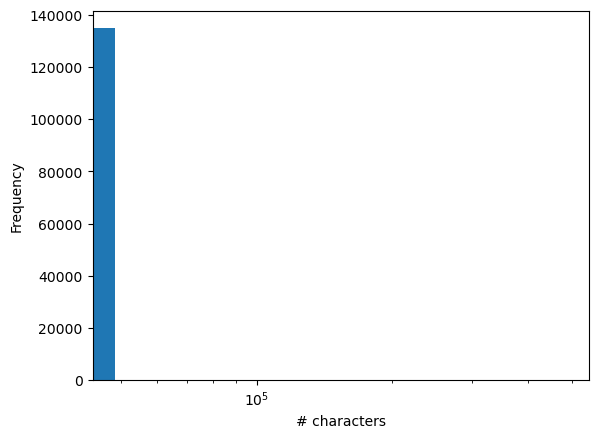

In [174]:
import matplotlib.pyplot as plt
plt.hist(res.sumChars.to_numpy())
plt.xlabel("# characters")
plt.ylabel("Frequency")
plt.xscale("log")

In [175]:
!curl https://2.bp.blogspot.com/-eGskF3n8_Ag/XE7F3P_de2I/AAAAAAAAHU8/WJw0un2nHqMGA8cFVtv_yFfpBVQJSYyVACK4BGAYYCw/s1600/Icon-Reddit.png > reddit.png
from wordcloud import WordCloud, ImageColorGenerator
from PIL import Image

mask = np.array(Image.open("reddit.png"))
text = " ".join([i for i in kdf.selftext.to_numpy() if len(i) > 0 and i != "[removed]" and i!="[deleted]"])

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 76004  100 76004    0     0   355k      0 --:--:-- --:--:-- --:--:--  355k


/Users/ivandominguez/anaconda3/lib/python3.11/site-packages/pyspark/pandas/utils.py:1038: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


/Users/ivandominguez/anaconda3/lib/python3.11/site-packages/pyspark/pandas/utils.py:1038: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


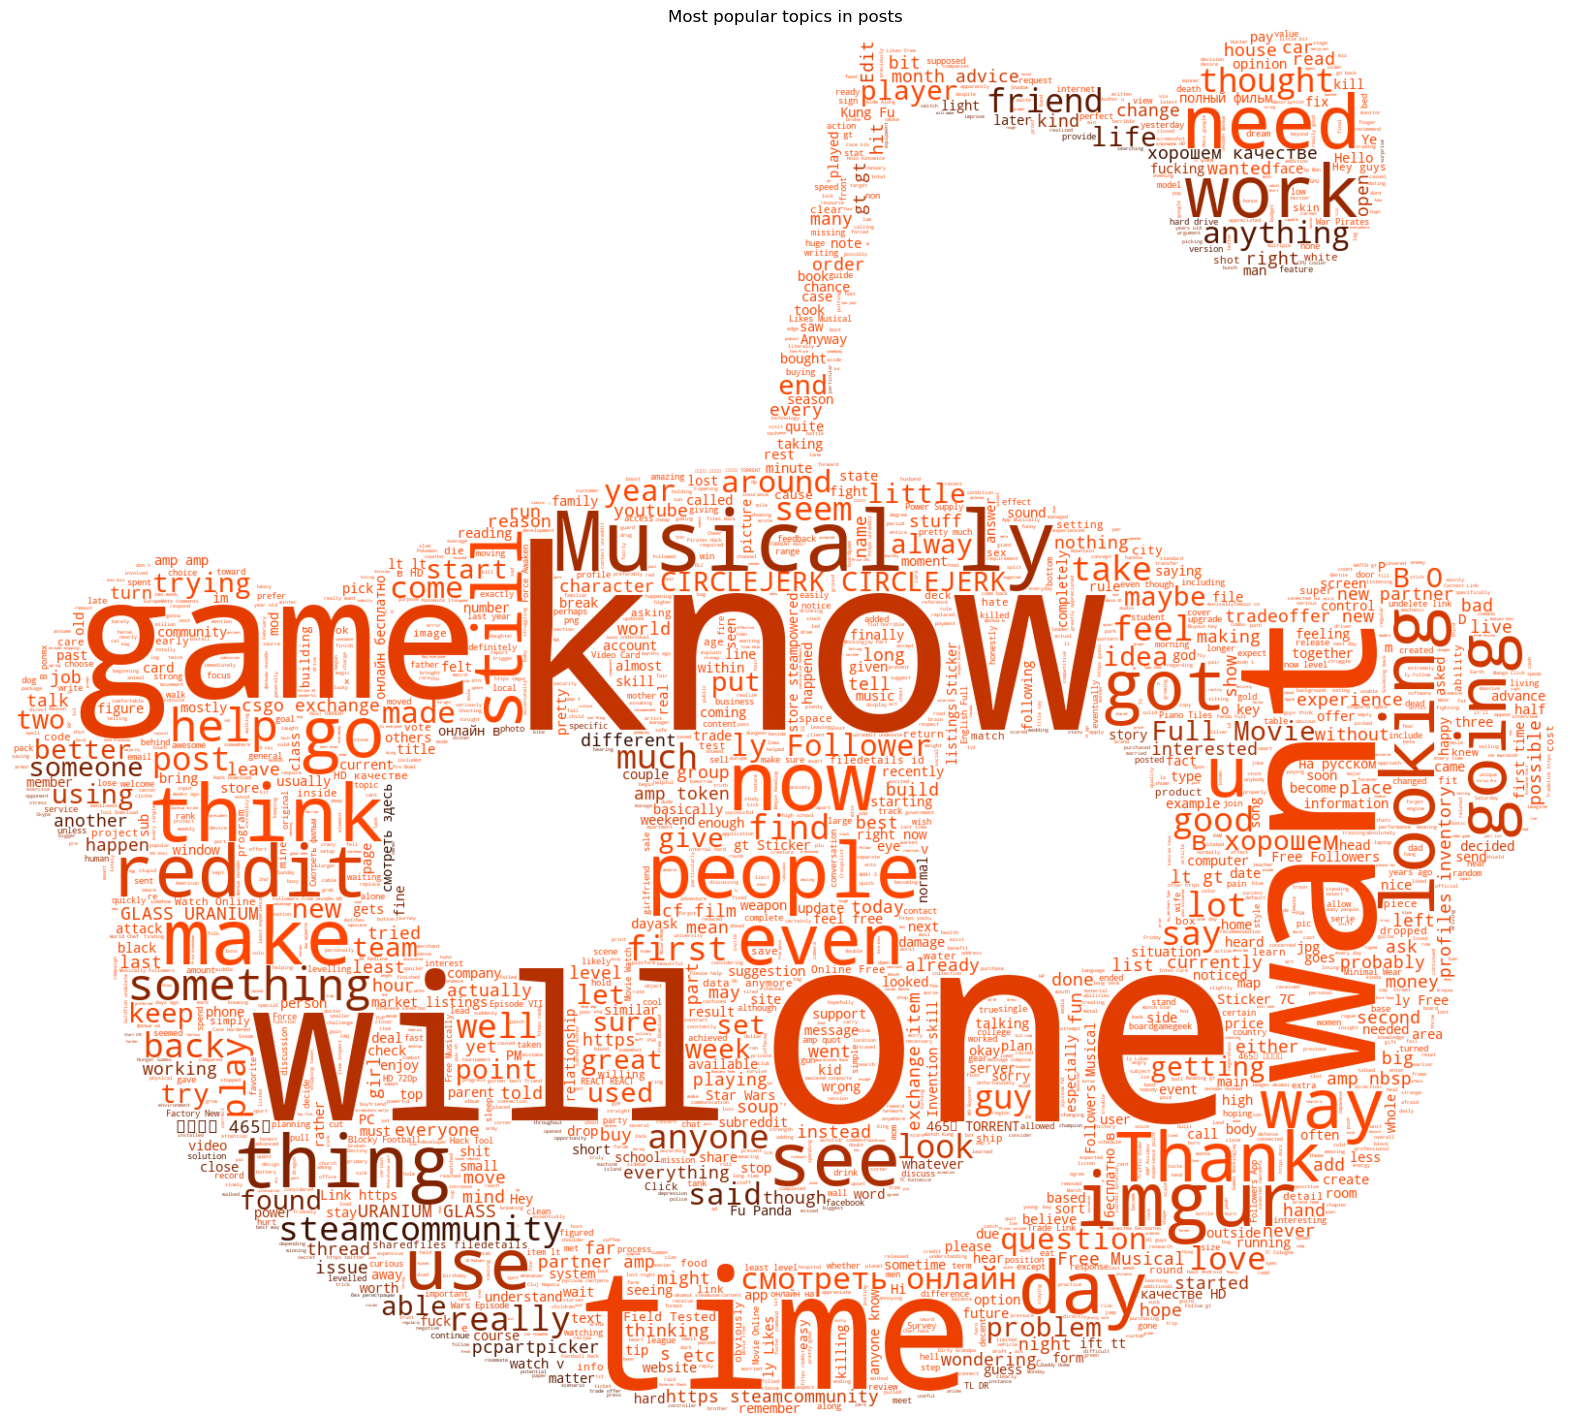

In [176]:
text = " ".join([i for i in kdf.selftext.to_numpy() if len(i) > 0 and i != "[removed]" and i!="[deleted]"])
wordcloud = WordCloud(max_words=5000, mask=~mask[:,:,0], background_color="white", mode="RGBA").generate(text)
# create coloring from image
image_colors = ImageColorGenerator(mask)
plt.figure(figsize=(20,20))
plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")
plt.title("Most popular topics in posts")
plt.axis("off");

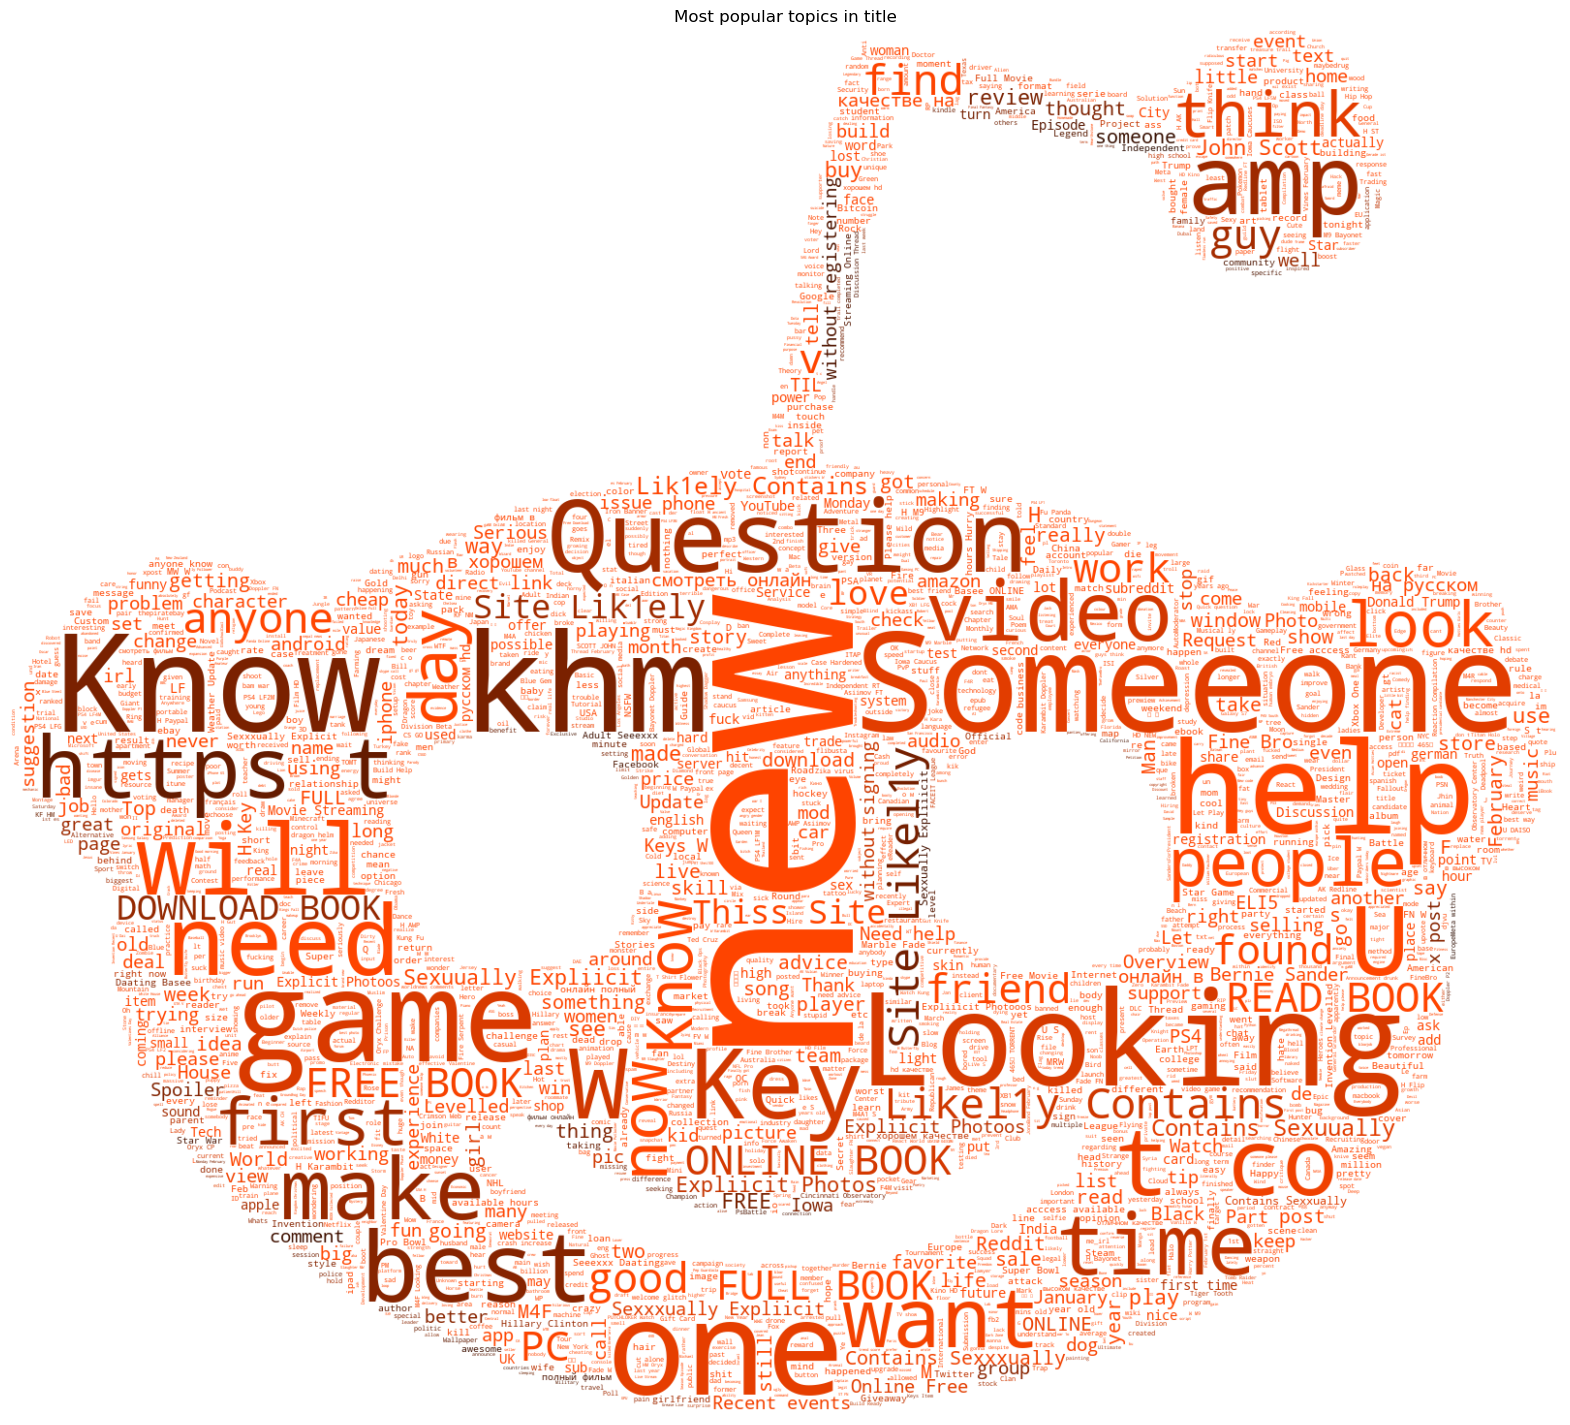

In [177]:
text = " ".join([i for i in kdf.title.to_numpy() if len(i) > 0 and i != "[removed]" and i!="[deleted]"])
wordcloud = WordCloud(max_words=5000, mask=~mask[:,:,0], background_color="white", mode="RGBA").generate(text)
# create coloring from image
image_colors = ImageColorGenerator(mask)
plt.figure(figsize=(20,20))
plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")
plt.title("Most popular topics in title")
plt.axis("off");

--------


<font size=10 color=red>Assignment question</font>

Choose a subreddit you like and build a worldcloud using Pandas on Spark. Feel free to change the mask or the colors...

--------
Answer: